This active learning pipeline builds a dataset $\mathcal{D}$ in two steps:
1. It finds a point in the design space $(x, t) \in \mathcal{X} = \mathbb{R}^2 \times \mathbb{R}$ that has highest utility in being added to the dataset $\mathcal{D}$. 
This is done by defining the utility $$u(x) = c(x)\times \sum_{t} \mathbb{H}(p(y = i|x, t, \mathcal{D}))$$ where $p(y = i|x, t, \mathcal{D})$ measures the probability of obtaining phase $i$ at $(x, t) \in \mathcal{X}$ in the design space, and $c(x)$ measures the cost of sampling $x$. Optimal $x^{*}$ is then obtained using:
$$ x^{*} = \argmax_{x} u(x) $$

2. For any point in the design space $x^{*} \in \mathcal{X}$, a temperature profile for measurement is obtained by repeatedly optimziing another utility $$v(t) = p(t=\mathrm{measurable}|x, \mathcal{D}) \times \mathbb{H}(p(y = i|x, t, \mathcal{D}))$$ where $p(t=\mathrm{measurable}|x, \mathcal{D})$ is the probability of sample at $x$ is being measurable at temperature $t$.
Currently, a batch optimization to sampling $\{t_{j}\}_{j=1}^{b}$ is used where in we sample all the maxima of $p(t=\mathrm{measurable}|x, \mathcal{D})$ for batch size $b$ using $ t_{b} = \argmax_{t} v(t)$.If no clear peaks were observed, we resort to a single temperature that has the highest utility.

In the above, $\mathbb{H}$ represents `marginal entropy` given by:
$$\mathbb{H}(y| x, \mathcal{D}) = -\sum_i p(y = i | x, \mathcal{D}) \log p(y = i | x, \mathcal{D})$$

# Setup

In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from scipy.signal import find_peaks

from VirtualSAS_theory import VirtualSAS_theory

from AFL.double_agent import *
from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 

from typing import Optional, Union, List, Tuple, Dict
import textwrap
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import matplotlib.transforms as mtransforms 
from matplotlib.colors import Normalize

### Create Virtual Instrument

In [28]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')
boundary_dataset.close()

reference_data_path = './SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)

# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')#, delim_whitespace=True)
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

### initial Dataset

In [29]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds['step'] = 0
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:       (sample: 6, q: 281, ds_dim: 3)
Coordinates:
  * q             (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * ds_dim        (ds_dim) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I             (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    I_noiseless   (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    dI            (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    design_space  (sample, ds_dim) int64 144B 40 0 5 40 10 5 ... 40 40 5 40 50 5
    phases        (sample) int64 48B 2 1 1 1 0 0
    step          (sample) int64 48B 0 0 0 0 0 0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [30]:
def minmax_normalize(arr: np.ndarray,
                    axis: Optional[Union[int, Tuple[int, ...]]] = None,
                    eps: float = 1e-8
                ) -> np.ndarray:
    """
    Min-max normalize a NumPy array along a given axis or globally.

    Parameters:
    -----------
    arr : np.ndarray
        Input array (1D or multi-dimensional).
    axis : Optional[int or Tuple[int, ...]]
        Axis or axes along which to normalize. If None, normalize globally.
    eps : float
        Small epsilon to avoid division by zero.

    Returns:
    --------
    normalized : np.ndarray
        Normalized array with same shape as input, scaled to [0, 1].
    """
    arr = np.asarray(arr)
    min_val = np.min(arr, axis=axis, keepdims=True)
    max_val = np.max(arr, axis=axis, keepdims=True)
    normalized = (arr - min_val) / (max_val - min_val + eps)
    return normalized

### Modeling hierarchical costs in different design variables

In [31]:
class DesignSpaceHierarchyCost(PipelineOp):
    def __init__(
        self,
        grid_variable: str = None,
        grid_dim:str =None,
        component_dim:str=None,
        variables_order : List[str] = None, # from highest to lowest cost
        variables_offsets : List[float] = None,
        output_variable: str = None,
        name: str = "DesignSpaceHierarchyCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[grid_variable], output_variable=output_variable
        )
        self.variables_order = variables_order
        self.variables_offsets = variables_offsets
        self.grid_variable = grid_variable
        self.grid_dim = grid_dim
        self.component_dim = component_dim
        self.iteration = 1

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Compute and store normalized cost over the full grid."""
        grid = dataset[self.grid_variable]

        cost_grid = self.evaluate_cost(query=grid)

        self.output[self.output_variable] = xr.DataArray(cost_grid, dims=self.grid_dim)
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Cost per sample evaluated on {self.input_variable}"

        return self
    
    def evaluate_cost(self,
                      query: xr.DataArray,
                    ) -> np.ndarray:
        """Compute cost for each query point using previously sampled data."""
        num_queries = query.shape[0]
        k = len(self.variables_order)
        output = np.zeros(num_queries)
        for i in range(num_queries):
            w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
            dim_cost = []
            for j in range(k):
                ell = 1/((w[j]*self.iteration)+1)
                x = query.sel({self.component_dim: self.variables_order[j]}).values[i]
                f_x_t = ell*np.exp(-(np.abs(x-self.variables_offsets[j])*ell))
                dim_cost.append(1-f_x_t)
            output[i] = np.prod(np.array(dim_cost))

        self.iteration += 1
        return output

### Modeling unknown feasibility constraints

In [32]:
class FeasibilityLabeler(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        output_variable: str = None,
        dim: str = "sample",
        name: str = "FeasibilityLabeler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=input_variable, 
            output_variable=output_variable,
        )
        self.dim = dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Label samples as feasible or infeasible based on cost."""
        labels = dataset[self.input_variable].values
        is_feasible = np.where(labels == 0, 0, 1)  # 1 for feasible, 0 for infeasible
        self.output[self.output_variable] = xr.DataArray(is_feasible, dims=[self.dim])
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Feasibility labels based on {self.input_variable}"

        return self

### Sample compositions

In [33]:
class UtilityCompositionSpace(PipelineOp):
    def __init__(
        self,
        input_variable: str = "acquisiton",
        cost_variables: Union[List[str], None] = None,
        composition_dims :  List[str]= ['protein', 'glycerol'],
        component_dim: str = "ds_dim",
        grid_variable:str = "design_space_grid",        
        output_variable: str = "composition_utility",
        name: str = "UtilityCompositionSpace",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable], 
            output_variable=output_variable
        )
        self.composition_dims = composition_dims
        self.cost_variable = cost_variables
        self.grid_variable = grid_variable 
        self.dim = component_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        grid = dataset[self.grid_variable]
        grid_composition = grid.sel({self.dim:self.composition_dims})
        unique_composition = grid_composition.to_pandas().drop_duplicates().reset_index(drop=True)

        x = unique_composition.values
        num_comps = len(unique_composition)
        ux = np.zeros(num_comps)

        Pr_yi_xt = dataset[self.input_variable].values 
        for i, xi in enumerate(x):
            squared_distances = np.sum((xi - grid_composition.values) ** 2, axis=1)
            all_temp_idx = np.argwhere(squared_distances<1e-5)

            Pr_yi_x = Pr_yi_xt[all_temp_idx,:].mean(axis=0) # marginalization over t
            ux_i =  -np.sum(np.log(Pr_yi_x) * Pr_yi_x, axis=-1) # Marginal entropy as the utility
            if self.cost_variable is not None:
                for var in self.cost_variable:
                    cost = dataset[var].values[all_temp_idx].mean() # marginalize over temperature
                    ux_i *= (1.0-cost)
            ux[i] = ux_i.item()
  
        coords = {"points": np.arange(num_comps)}
        for i, name in enumerate(self.composition_dims):
            coords[name] = ("points", x[:, i])
        output = xr.DataArray(ux, dims=("points",), coords=coords)
        self.output[self.output_variable] = output # type: ignore
        self.output[self.output_variable].attrs["description"] = "Utility calculated for arbitrary point in the composition space" # type: ignore

        return self

class QueryStrategyCompositionSpace(PipelineOp):
    def __init__(
        self,
        input_variable: str = "composition_utility",
        composition_dims :  List[str] = ["protein", "glycerol"],
        output_variable: str = "next_sample",
        name: str = "QueryStrategyCompositionSpace",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable], 
            output_variable=output_variable
        )
        self.composition_dims = composition_dims

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Implements argmax query strategy.

        When the utility is marginal entropy given by:
        H[y | x, D] = -\sum_i p(y = i | x, D) \log p(y = i | x, D). 
        for any dataset D = (X, Y), this results in uncertainity sampling. 
        """
        ux = dataset[self.input_variable]
        x = np.column_stack([ux.coords[name].values for name in self.composition_dims])
        x_opt = x[np.argmax(ux.values).item(),:] # x^* = argmax_{x} u(x)

        output = xr.DataArray(x_opt.reshape(-1, len(self.composition_dims)),
                              dims=("n_counts", "comp_dim"),
                              coords={"comp_dim": self.composition_dims}
                            )
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = textwrap.dedent("""
        Optimal composition to be added to the dataset
        that maximizes the utility of acquiring a temperature measurement.
        """).strip()
        return self


### Sample temperatures at a composition

In [34]:
class UtilityTemperatureAxis(PipelineOp):
    def __init__(
        self,
        input_variable: str = "acquisiton",
        cost_variables: Union[List[str], None] = ["feasibility_y_prob"],
        target_composition_variable : str = "next_composition",
        composition_dims :  List[str]= ['protein', 'glycerol'],
        temperature_dim:str = "temperature",
        grid_variable:str = "design_space_grid",        
        component_dim: str = "ds_dim",
        output_variable: str = "temperature_utility",
        name: str = "UtilityTemperatureAxis",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable]+cost_variables, 
            output_variable=output_variable
        )
        self.composition_dims = composition_dims
        self.temperature_dim = temperature_dim
        self.target_composition_variable = target_composition_variable       
        self.cost_variable = cost_variables
        self.grid_variable = grid_variable 
        self.dim = component_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        next_sample = dataset[self.target_composition_variable]
        x_opt = next_sample.values

        grid = dataset[self.grid_variable]
        grid_composition = grid.sel({self.dim:self.composition_dims}).values
        grid_temperatures = grid.sel({self.dim:self.temperature_dim}).values

        squared_distances = np.sum((x_opt - grid_composition) ** 2, axis=1)
        x_opt_temp_idx = np.argwhere(squared_distances<1e-5)

        u_xt = dataset[self.input_variable] # utility u(x,t)

        # Extract utility at x : u_{x}(t)
        ux_t = u_xt.values[x_opt_temp_idx].copy() # type: ignore
        if self.cost_variable is not None:
            for var in self.cost_variable:
                # Here the cost corresponds to Pr(t=measurable|x)
                # We expect the `var` to result in a Nx2 shaped array
                # where Pr(t=measurable|x) is in index 1
                cost = dataset[var].values[x_opt_temp_idx,1] 
                ux_t *= cost

        output = xr.DataArray(ux_t.squeeze(), 
                              dims="temp_dim",
                              coords={"temp_dim": grid_temperatures[x_opt_temp_idx].squeeze()}
                            )
        self.output[self.output_variable] = output # type: ignore
        self.output[self.output_variable].attrs["description"] = "Utility calculated along the temperature axis" # type: ignore

        return self

class QueryStrategyTemperatureAxis(PipelineOp):
    def __init__(
        self,
        input_variable: str = "temperature_utility",
        output_variable: str = "next_sample",
        name: str = "QueryStrategyTemperatureAxis",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[input_variable], 
            output_variable=output_variable
        )
    
    def calculate(self, dataset: xr.Dataset) -> Self:
        vt = dataset[self.input_variable]
        t = vt.coords["temp_dim"]

        t_opt = self.find_x_peaks(t, vt.values)
        
        output = xr.DataArray(np.asarray(t_opt).reshape(-1),
                              dims=("n_next"),
                            )
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = textwrap.dedent("""
        Optimal composition-temperature combination to be added to the dataset
        that maximizes the utility of acquiring a temperature measurement at any given 
        composition.
        """).strip()
        return self

    def find_x_peaks(self, x, f, **kwargs):
        """
        Find peaks in f(x). 
        If no clear peaks are found, return x[argmax(f)] instead.

        Parameters
        ----------
        x : array-like
            1D array of x values.
        f : array-like
            1D array of function values f(x).
        **kwargs : dict
            Extra keyword arguments passed to scipy.signal.find_peaks,
            e.g. height=..., distance=..., prominence=...

        Returns
        -------
        xb : ndarray
            Sorted array of x values where peaks occur, or argmax(f) if none.
        """
        x = np.asarray(x)
        f = np.asarray(f).squeeze()

        # Use scipy to find peak indices
        peaks, _ = find_peaks(f, **kwargs)

        if len(peaks) > 0:
            xb = x[peaks]
        else:
            xb = np.array([x[np.argmax(f)]])  # fallback to global max

        return np.sort(xb)


### Compute cost of a measurement and synthesis

In [35]:
class ExperimentCost(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        input_dim : str = None,
        composition_dims_cost :  Dict = None,
        temperature_dim_cost: Dict[str, float] = None,
        output_variable: str = None,
        name: str = "ExperimentCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=input_variable, output_variable=output_variable
        )
        self.composition_dims_cost = composition_dims_cost
        self.temperature_dim_cost = temperature_dim_cost
        self.input_dim = input_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        data = dataset[self.input_variable]
        expense = 0.0

        # Compute cost of using sample stocks
        composition_names = [key for key in self.composition_dims_cost.keys()]
        compositions = data.sel({self.input_dim:composition_names}).values
        _, indices = np.unique(compositions, axis=0, return_index=True)
        for name, val in self.composition_dims_cost.items():
            sampled_quantity = data.sel({self.input_dim:name}).values
            expense += (sampled_quantity[indices]*val).sum()

        # Compute cost of temperature modulation
        name, val = next(iter(self.temperature_dim_cost.items()))
        sampled_temperatures = data.sel({self.input_dim:name}).values
        for i in range(sampled_temperatures.shape[0]):
            if i>=1:
                expense += val*np.abs(sampled_temperatures[i] - sampled_temperatures[i-1])
            else:
                expense += val*np.abs(sampled_temperatures[i] - 27.0)

        # Store result
        output = xr.DataArray(expense)
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = "Total cost current experiment took so far."

        return self

### Creatte the pipeline for active learning

In [36]:
gp_params_mcmc = {"num_samples":20, "num_warmup":20, "method":"mcmc", "verbose":False}

In [37]:
with Pipeline(name = "phase_boundaries") as p:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phase",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-PhaseLabels",
    )

    DesignSpaceHierarchyCost(
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        component_dim="ds_dim",
        variables_order=['protein', 'glycerol'],
        variables_offsets=[0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name="CompositionTemperatureHierarchyCost",
    ) 

    UtilityCompositionSpace(
        input_variable = 'phase_y_prob',
        cost_variables=["hierarchy_cost"],
        composition_dims = ['protein', 'glycerol'],
        grid_variable = "design_space_grid",        
        component_dim = "ds_dim",
        output_variable = "composition_utility",
        name = "UtilityCompositionSpace",
    )
    
    QueryStrategyCompositionSpace(
        input_variable = "composition_utility",
        composition_dims = ["protein", "glycerol"],
        output_variable = "next_composition",
        name = "QueryStrategyCompositionSpace",
    )
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    UtilityTemperatureAxis(
        input_variable = "phase_entropy",
        cost_variables = ["feasibility_y_prob"],
        target_composition_variable = "next_composition",
        composition_dims = ['protein', 'glycerol'],
        temperature_dim = "temperature",
        grid_variable = "design_space_grid",        
        component_dim= "ds_dim",
        output_variable = "temperature_utility",
        name = "UtilityTemperatureAxis",
        )
    QueryStrategyTemperatureAxis(
        input_variable = "temperature_utility",
        output_variable = "next_temperature",
        name = "QueryStrategyTemperatureAxis",
    )

p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize>                       design_space_grid ---> normalized_design_space_grid
3  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phase_y_prob']
4  ) <CompositionTemperatureHierarchyCost> ['normalized_design_space_grid'] ---> hierarchy_cost
5  ) <UtilityCompositionSpace>           phase_y_prob ---> composition_utility
6  ) <QueryStrategyCompositionSpace>     composition_utility ---> next_composition
7  ) <FeasibilityLabeler>                phases ---> feasibility_labels
8  ) <DirichletGPExtrapolator-FeasibilityLabels> ['normalized_design_space', 'feasibility_labels', 'normalized_design_

In [38]:
expense = ExperimentCost(
        input_variable="design_space",
        input_dim="ds_dim",
        composition_dims_cost={"protein":10.0, "glycerol" :5.0},
        temperature_dim_cost={"temperature" : 20.0},
        output_variable="expense",
        name="ExperimentCost"
    )

### Test Pipeline

In [39]:
ds_result = p.calculate(ds_init)
ds_result

  0%|          | 0/11 [00:00<?, ?it/s]

<xarray.Dataset> Size: 1MB
Dimensions:                       (q: 281, ds_dim: 3, sample: 6, ds_grid: 8000,
                                   phase_n_classes: 3, points: 400,
                                   comp_dim: 2, n_counts: 1,
                                   feasibility_n_classes: 2, temp_dim: 20,
                                   n_next: 1)
Coordinates:
  * q                             (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                        (ds_dim) object 24B 'protein' ... 'glycerol'
  * points                        (points) int64 3kB 0 1 2 3 ... 396 397 398 399
    protein                       (points) float64 3kB 0.0 0.0 0.0 ... 80.0 80.0
    glycerol                      (points) float64 3kB 0.0 0.6316 ... 11.37 12.0
  * comp_dim                      (comp_dim) <U8 64B 'protein' 'glycerol'
  * temp_dim                      (temp_dim) float64 160B 0.0 2.632 ... 50.0
Dimensions without coordinates: sample, ds_grid, phase_n_classes, n_counts,
                                feasibility_n_classes, n_next
Data variables: (12/23)
    I                             (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                   (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                            (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                  (sample, ds_dim) int64 144B 40 0 5 ... 40 50 5
    phases                        (sample) int64 48B 2 1 1 1 0 0
    step                          (sample) int64 48B 0 0 0 0 0 0
    ...                            ...
    feasibility_mean              (ds_grid) int64 64kB 1 1 1 1 1 1 ... 1 1 1 1 0
    feasibility_entropy           (ds_grid) float64 64kB 0.6157 0.6154 ... 0.693
    feasibility_y_prob            (ds_grid, feasibility_n_classes) float64 128kB ...
    feasibility_entropy_gradient  (ds_grid, ds_dim) float32 96kB -0.1793 ... ...
    temperature_utility           (temp_dim) float64 160B 0.7923 ... 0.4688
    next_temperature              (n_next) float64 8B 0.0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [40]:
out = expense.calculate(ds_result)
out.output['expense'].values

array(1965.)

In [41]:
def plot_progress(ds, 
                  design_space_variable, 
                  grid_variable, 
                  design_space_dim, 
                  composition_variables,
                  temperature_variable,
                  labels_variable,
                  phase_probability_variable,
                  feasibilty_probability_variable
                  ):
    """Plot cost and entropy in 3D."""
    fig, axs  = plt.subplots(1,3, 
                             figsize=(4*3, 4*1), 
                             subplot_kw={"projection":'3d'},
                             )
    axs = axs.flatten()
    fig.subplots_adjust(wspace=0.5, hspace=0.5)

    ax = axs[0]
    x = ds[design_space_variable].sel({design_space_dim:composition_variables[0]}).values
    y = ds[design_space_variable].sel({design_space_dim:composition_variables[1]}).values
    z = ds[design_space_variable].sel({design_space_dim:temperature_variable}).values
    ax.scatter(x, y, z, c=ds[labels_variable].values)
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)

    xg = ds[grid_variable].sel({design_space_dim:composition_variables[0]}).values
    yg = ds[grid_variable].sel({design_space_dim:composition_variables[1]}).values
    zg = ds[grid_variable].sel({design_space_dim:temperature_variable}).values    

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax = axs[1]
    mappable = ax.scatter(xg, yg, zg,
        c=ds[phase_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(phase_probability_variable)

    ax = axs[2]
    mappable = ax.scatter(xg, yg, zg,
        c=ds[feasibilty_probability_variable].values[:,1],
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(feasibilty_probability_variable)

    for ax in axs:
        ax.set_xlabel(composition_variables[0])
        ax.set_ylabel(composition_variables[1])
        ax.set_zlabel(temperature_variable, labelpad=-2)
    plt.tight_layout()

    return fig, axs

In [42]:
def plot_sampling(ds):
    fig = plt.figure(figsize=(10, 5))
    gs = gridspec.GridSpec(nrows=2, 
                        ncols=2, 
                        height_ratios=[0.05, 0.95], 
                        hspace=0.05, wspace=0.25)

    ax_cb = fig.add_subplot(gs[0, 0])       # colorbar axis above left plot
    ax_comp = fig.add_subplot(gs[1, 0])      # 2D KDE plot
    ax_temp = fig.add_subplot(gs[1, 1])     # 1D KDE plot

    ux = ds["composition_utility"]
    x = np.column_stack([ux.coords[name].values for name in ["protein", "glycerol"]])
    mappable = ax_comp.tricontourf(x[:,0], x[:,1], ux)
    cbar = fig.colorbar(mappable, cax=ax_cb, orientation='horizontal')
    cbar.set_label(r"$\sum_{t}u(x,t)$", labelpad=15)
    ax_cb.xaxis.set_ticks_position('top')
    ax_cb.xaxis.set_label_position('top')

    ax_comp.scatter(ds.design_space.sel({"ds_dim":"protein"}).values ,
            ds.design_space.sel({"ds_dim":"glycerol"}).values,
            color = "k"
        )
    ax_comp.scatter(ds.next_composition.sel({"comp_dim":"protein"}).values ,
            ds.next_composition.sel({"comp_dim":"glycerol"}).values,
            color = "tab:red",
            label = "Selected for next iteration"
        )
    ax_comp.set_xlim([0.0, 80.0])
    ax_comp.set_ylim([0.0, 12.0])
    ax_comp.legend()
    ax_comp.set_xlabel("protein")
    ax_comp.set_ylabel("glycerol")

    ax_temp.plot(
        ds.temperature_utility.temp_dim.values,
        ds.temperature_utility.values,
        )
    t_opt = ds.next_temperature.values 
    for ti in t_opt:
        ax_temp.axvline(ti, ls='--', color="k")
    ax_temp.set_xlabel("Temperature")
    ax_temp.set_ylabel(r"$v(t)$")
    

## Run AL

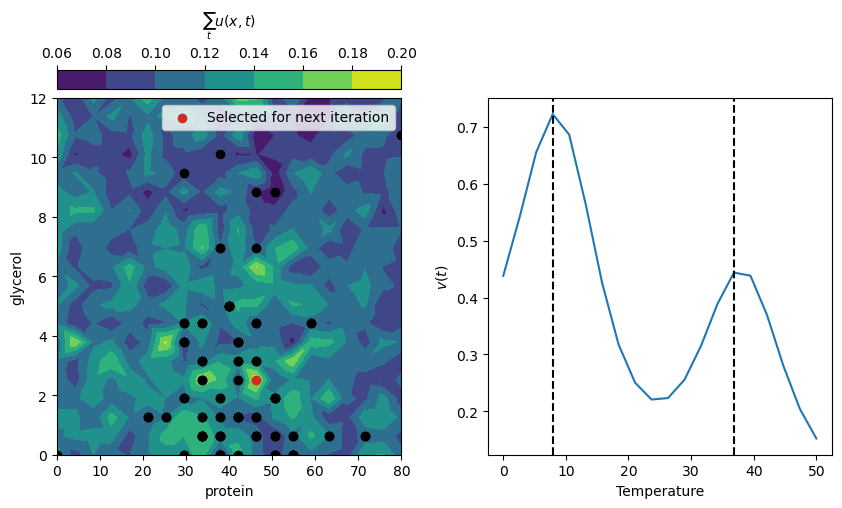

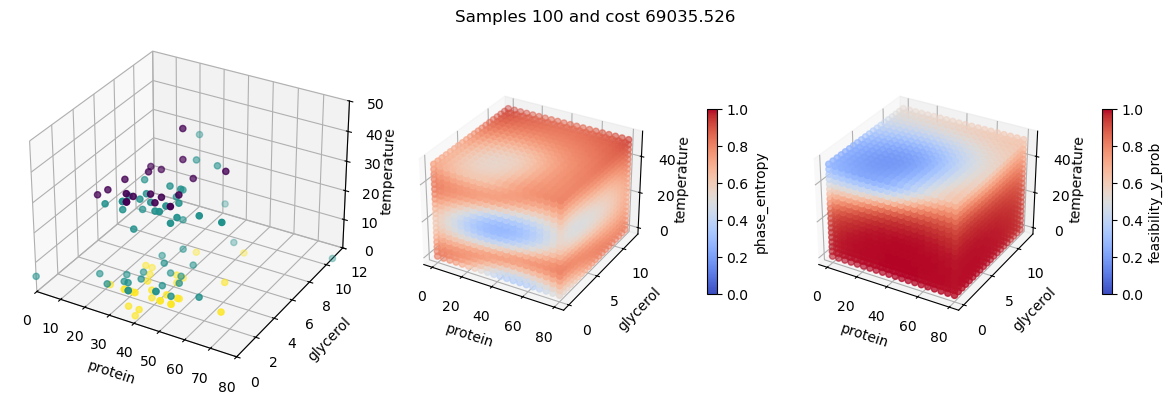

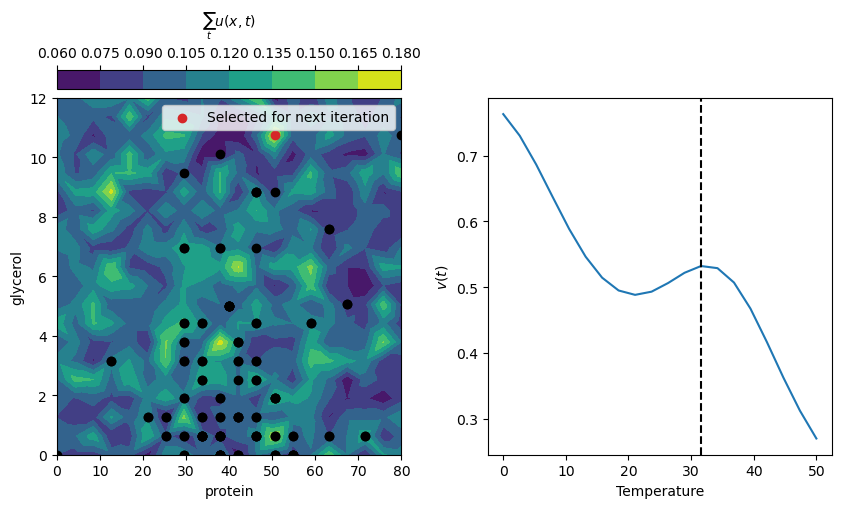

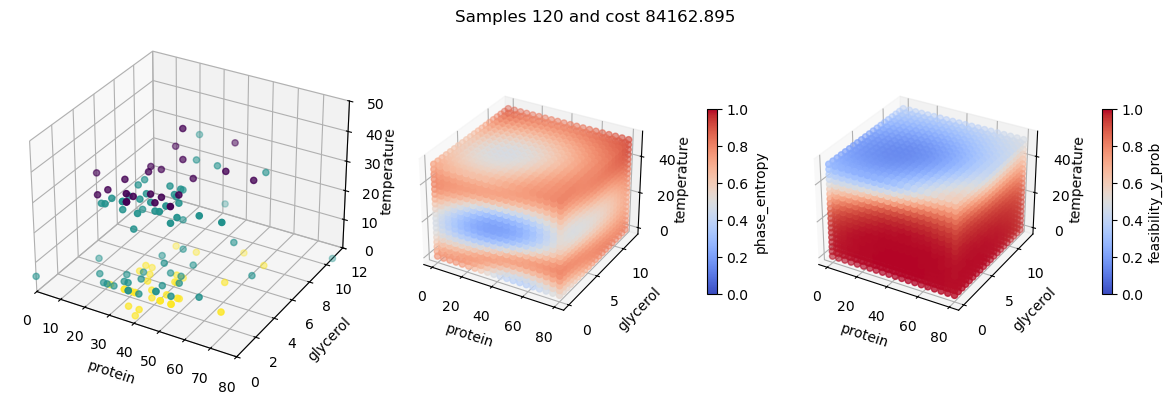

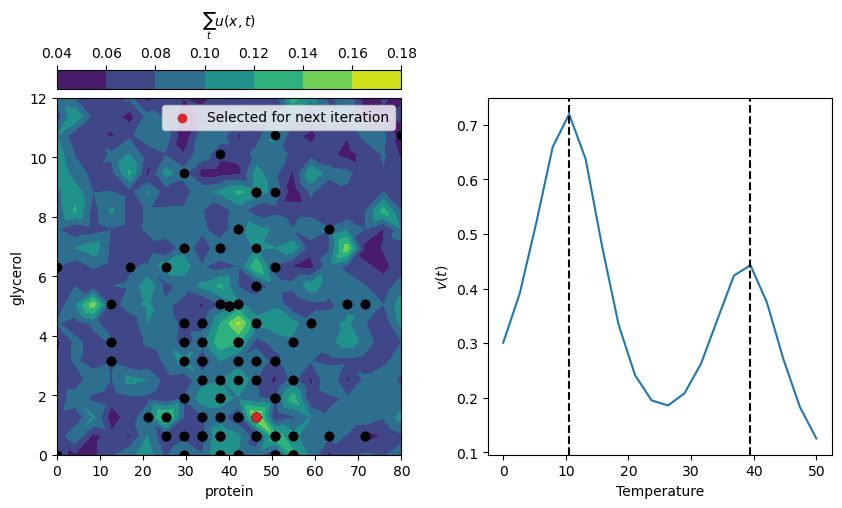

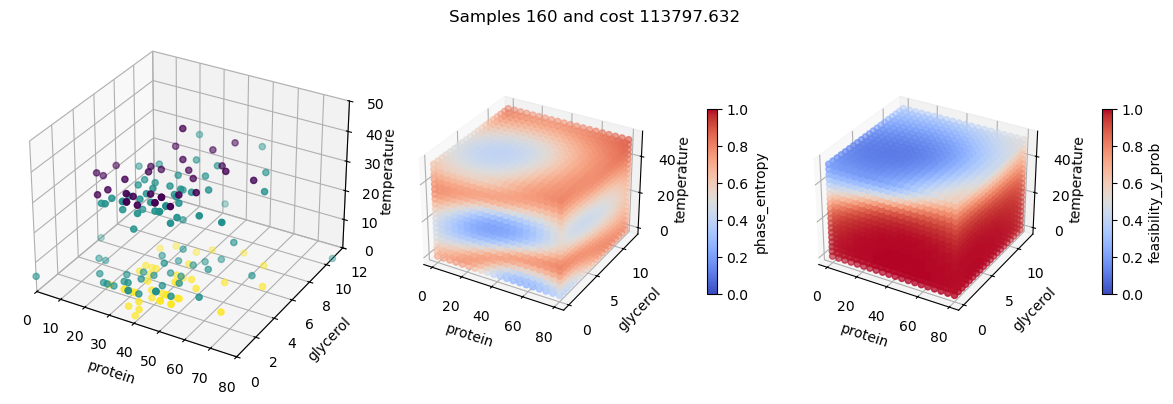

In [43]:
ds_running = ds_init.copy() 
ds_result = p.calculate(ds_init, disable_progress_bar=True)
n_measurements = 200
step = 0
while len(ds_running.sample) < n_measurements:
    ds_new = []
    for t in ds_result.next_temperature.values:
        sample = {"protein": ds_result.next_composition.sel({"comp_dim":"protein"}).values.item(),
                "glycerol" : ds_result.next_composition.sel({"comp_dim":"glycerol"}).values.item(),
                "temperature" : t.item()
        }  
        ds = inst_client.simple_expose(sample)
        ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
        ds['phases'] = int(ds.attrs['labels'])
        ds_new.append(ds)

    ds_new = xr.concat(ds_new, dim='sample')
    ds_running = xr.concat([ds_running, ds_new], dim='sample')
    ds_result = p.calculate(ds_running, disable_progress_bar=True)
    out = expense.calculate(ds_running)
    if (100*(len(ds_running.sample)/n_measurements))%10==0:
        plot_sampling(ds_result)
        plt.show()
        
        fig, axs = plot_progress(ds_result, 
                    "design_space", 
                    "design_space_grid", 
                    "ds_dim", 
                    ['protein', 'glycerol'],
                    "temperature",
                    "phases",
                    "phase_entropy",
                    "feasibility_y_prob"
                    )
        fig.suptitle(f"Samples {len(ds_running.sample)} " + 
                    f"and cost {out.output['expense'].values.item():.3f}")
        plt.show()

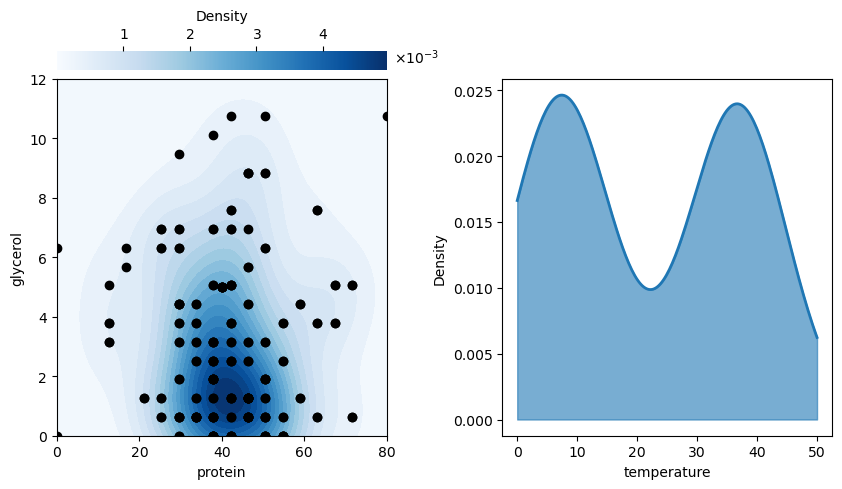

In [46]:
design_space_variable = "design_space"
design_space_dim = "ds_dim"
composition_variables = ["protein", "glycerol"]
temperature_variable = "temperature"

x = ds_running[design_space_variable].sel({design_space_dim: composition_variables[0]}).values
y = ds_running[design_space_variable].sel({design_space_dim: composition_variables[1]}).values
z = ds_running[design_space_variable].sel({design_space_dim: temperature_variable}).values

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(nrows=2, 
                       ncols=2, 
                       height_ratios=[0.05, 0.95], 
                       hspace=0.05, wspace=0.35)

ax_cb = fig.add_subplot(gs[0, 0])       # colorbar axis above left plot
ax_kde = fig.add_subplot(gs[1, 0])      # 2D KDE plot
ax_hist = fig.add_subplot(gs[1, 1])     # 1D KDE plot

# --- 2D KDE of (x, y) ---
xy = np.vstack([x, y])

# Grid
xgrid = np.linspace(0, 80, 100)
ygrid = np.linspace(0, 12, 100)
X, Y = np.meshgrid(xgrid, ygrid)
# Plot 2D density
positions = np.vstack([X.ravel(), Y.ravel()])
kde_xy = gaussian_kde(xy, bw_method=0.5)
Z = np.reshape(kde_xy(positions).T, X.shape)
cf = ax_kde.contourf(X, Y, Z, levels=20, cmap='Blues')
ax_kde.scatter(x,y, color="k")
ax_kde.set_xlabel(composition_variables[0])
ax_kde.set_ylabel(composition_variables[1])
ax_kde.set_xlim([0.0, 80.0])
ax_kde.set_ylim([0.0, 12.0])

# Add horizontal colorbar above ax_kde
norm = Normalize(vmin=Z.min(), vmax=Z.max())
sm = ScalarMappable(norm=norm, cmap='Blues')
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
cbar.set_label("Density", labelpad=5)
ax_cb.xaxis.set_ticks_position('top')
ax_cb.xaxis.set_label_position('top')

# Use scientific notation with offset (e.g., 1e-3)
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))  # force sci notation if outside range
ax_cb.xaxis.set_major_formatter(formatter)
offset_text = ax_cb.xaxis.get_offset_text()
# Anchor left and top as before
offset_text.set_horizontalalignment('left')
offset_text.set_verticalalignment('top')
# Remove the default transform and set a new one with an offset in display coords
trans = offset_text.get_transform()  # usually data or axes coords
# Add an offset in display coords (pixels): x=+20 pixels, y=-10 pixels (down)
offset = mtransforms.ScaledTranslation(5/72, -18/72, fig.dpi_scale_trans)
offset_text.set_transform(trans + offset) 


# Remove cb axis border for aesthetics
for spine in ax_cb.spines.values():
    spine.set_visible(False)

# --- 1D KDE of z ---
kde_z = gaussian_kde(z, bw_method=0.5)
zgrid = np.linspace(z.min(), z.max(), 200)
density = kde_z(zgrid)

ax_hist.fill_between(zgrid, density, color="tab:blue", alpha=0.6)
ax_hist.plot(zgrid, density, color="tab:blue", lw=2.0)
ax_hist.set_xlabel(temperature_variable)
ax_hist.set_ylabel("Density")

plt.show()


In [47]:
ds_result.to_netcdf("./results/product_space_nmax_temp/ds.nc")